In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\data\processed\clean.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(X.shape, y.shape)
print(X.dtypes.value_counts())

(7043, 19) (7043,)
str        15
int64       2
float64     2
Name: count, dtype: int64


In [4]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 30)


C:\Users\pradh\AppData\Local\Temp\ipykernel_17716\2771176483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 30)
Test shape: (1409, 30)
Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [7]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8414012245214291
PR-AUC: 0.6305982903948586

Confusion Matrix:
[[749 286]
 [ 80 294]]


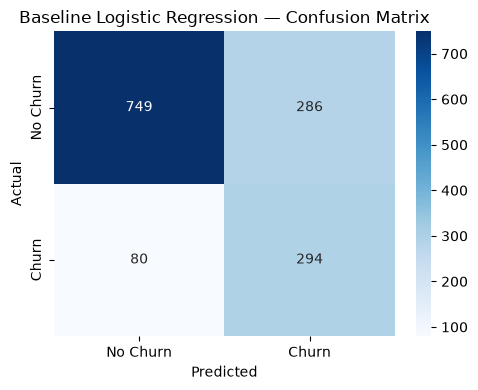

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Baseline Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [9]:
import joblib
joblib.dump(baseline_pipeline, "../models/baseline_logreg.pkl")

['../models/baseline_logreg.pkl']

In [10]:
import joblib
import os

save_path = r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\baseline_logreg.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(baseline_pipeline, save_path)
print("Saved to:", save_path)

Saved to: C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\baseline_logreg.pkl


In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# scale_pos_weight handles the imbalance (similar role to class_weight="balanced")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 2.768561872909699
Classification Report (XGBoost):
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.838821721046785
PR-AUC: 0.6527177301524731

Confusion Matrix:
[[765 270]
 [ 80 294]]


In [12]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("Classification Report (LightGBM):")
print(classification_report(y_test, y_pred_lgbm, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm))
print("PR-AUC:", average_precision_score(y_test, y_proba_lgbm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

Classification Report (LightGBM):
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8377289519233253
PR-AUC: 0.6535851167736805

Confusion Matrix:
[[763 272]
 [ 79 295]]


In [13]:
import joblib

save_path = r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\lgbm_churn_model.pkl"
joblib.dump(lgbm_model, save_path)
print("Saved to:", save_path)

Saved to: C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\lgbm_churn_model.pkl


c:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


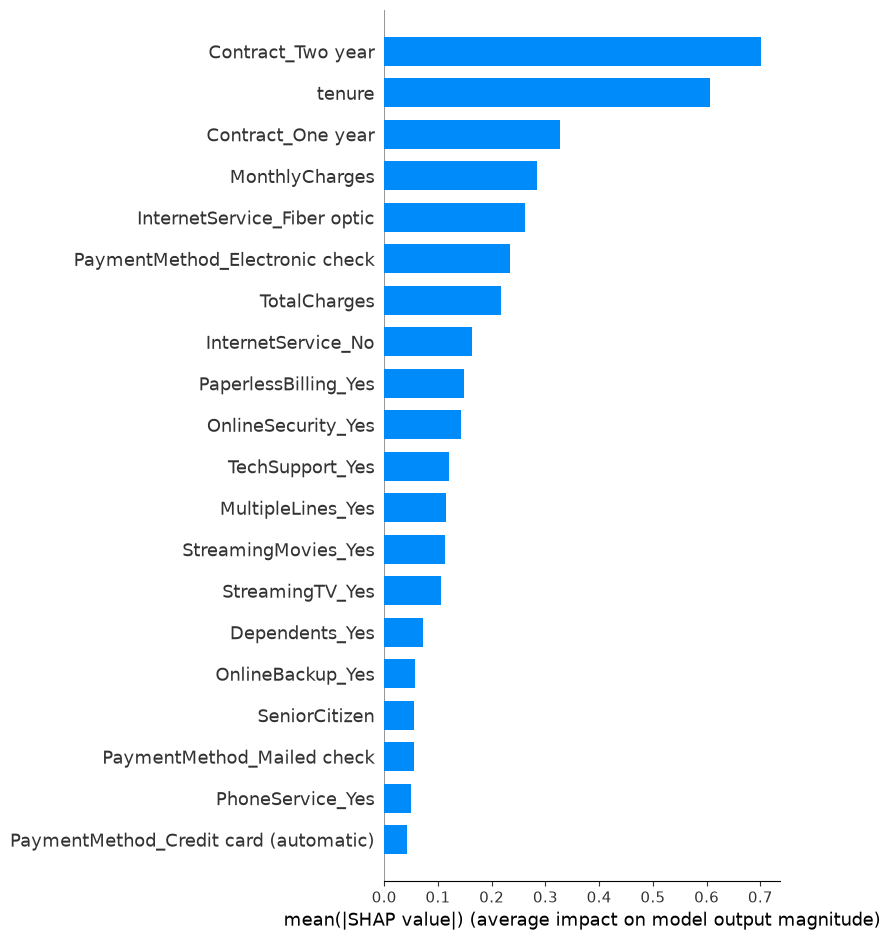

In [14]:
import shap

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, LightGBM's TreeExplainer usually returns
# a single array (class 1 / churn probability contribution)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

shap.summary_plot(shap_values_churn, X_test, plot_type="bar")

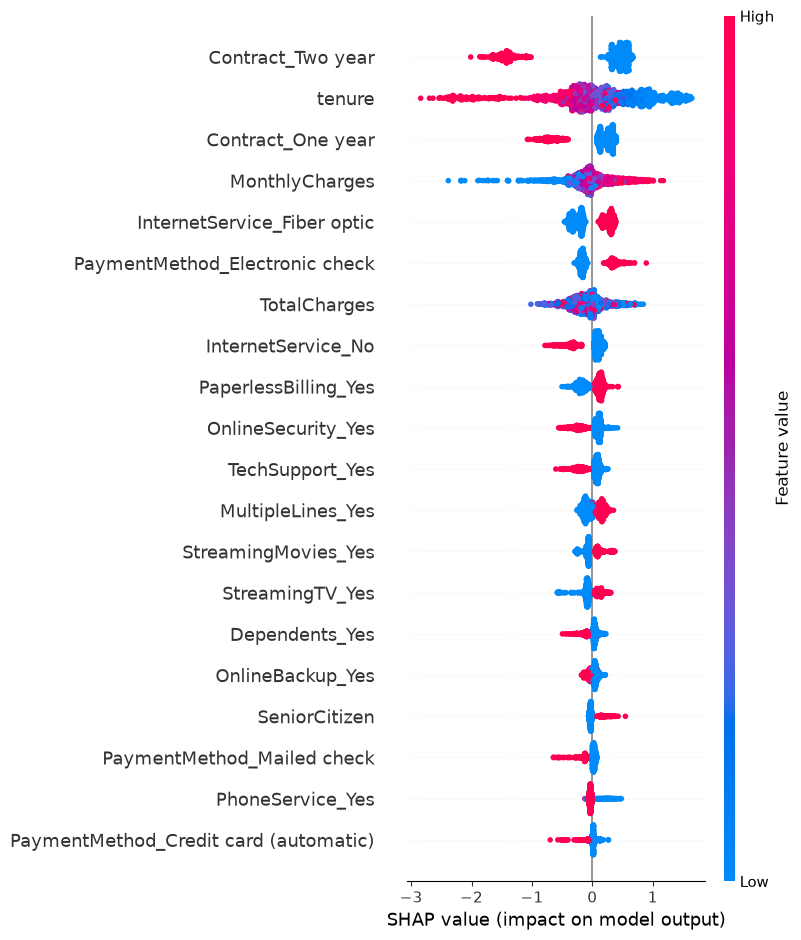

In [15]:
shap.summary_plot(shap_values_churn, X_test)

Predicted churn probability: 0.9728286358508097
Actual outcome: 1


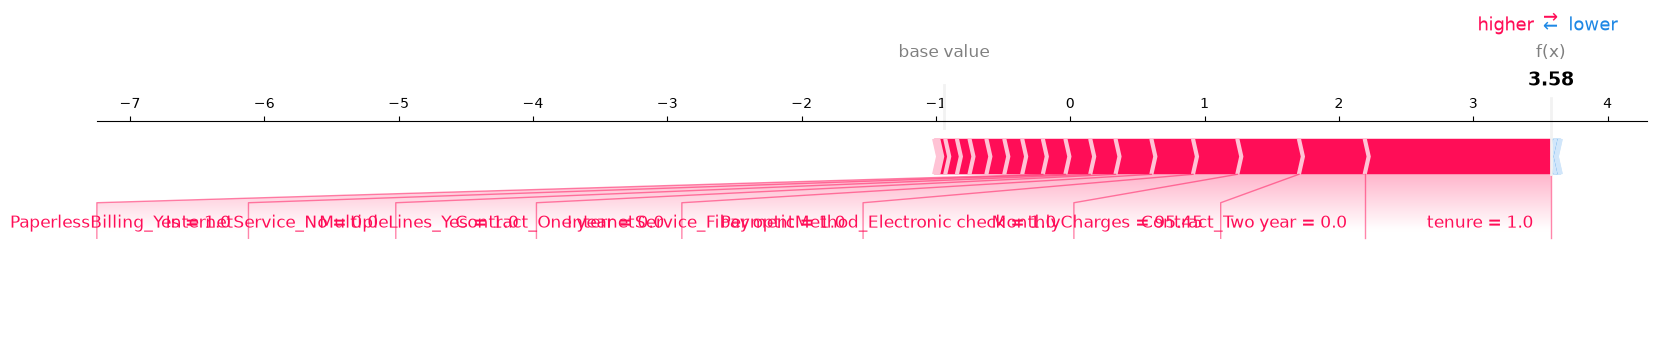

In [16]:
# Pick a customer the model thinks is high-risk
idx = y_proba_lgbm.argmax()  # highest churn probability in the test set
print("Predicted churn probability:", y_proba_lgbm[idx])
print("Actual outcome:", y_test.iloc[idx])

shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    shap_values_churn[idx],
    X_test.iloc[idx],
    matplotlib=True
)

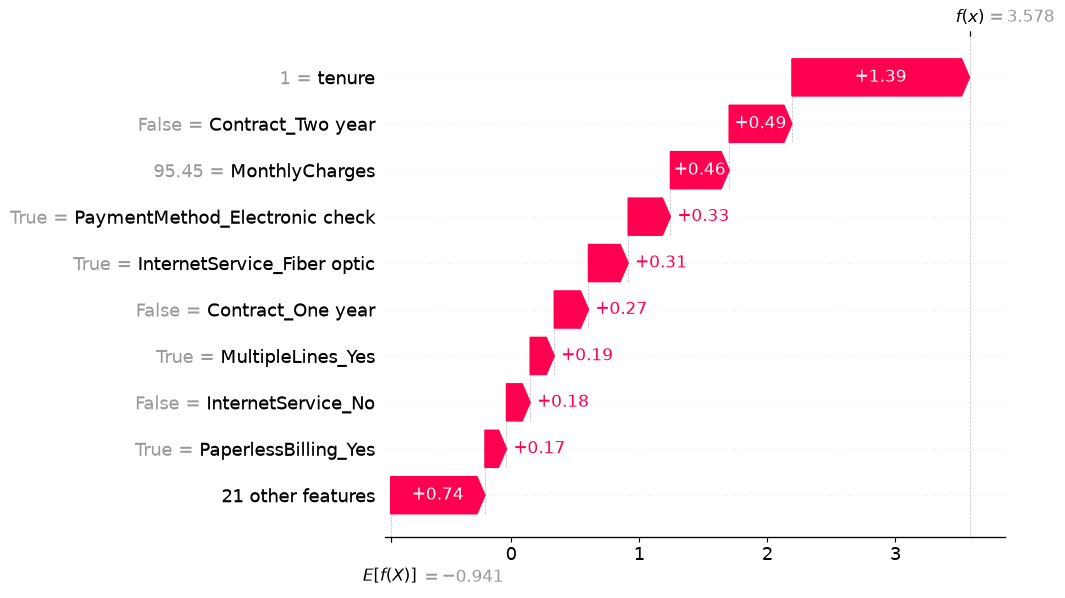

In [17]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_churn[idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist()
    )
)

In [18]:
import pandas as pd

results_df = X_test.copy()
results_df["actual_churn"] = y_test.values
results_df["churn_probability"] = y_proba_lgbm

def risk_bucket(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

results_df["risk_segment"] = results_df["churn_probability"].apply(risk_bucket)

segment_summary = results_df.groupby("risk_segment").agg(
    customers=("actual_churn", "count"),
    actual_churn_rate=("actual_churn", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean")
).sort_values("actual_churn_rate", ascending=False)

print(segment_summary)

              customers  actual_churn_rate  avg_monthly_charges
risk_segment                                                   
High Risk           332           0.632530            77.056928
Medium Risk         321           0.330218            69.617290
Low Risk            756           0.076720            56.046495


In [19]:
# Assumptions (state these clearly — interviewers will ask)
avg_monthly_revenue_per_churner = results_df[results_df["actual_churn"] == 1]["MonthlyCharges"].mean()
retention_offer_cost = 15          # e.g. discount/incentive cost per targeted customer, in $ or ₹
retention_success_rate = 0.30      # assumed % of contacted high-risk churners who are retained
months_saved_per_retained = 12     # assume 1 year of retained revenue as the value of a save

high_risk = results_df[results_df["risk_segment"] == "High Risk"]
actual_churners_in_high_risk = high_risk["actual_churn"].sum()

customers_targeted = len(high_risk)
customers_retained = actual_churners_in_high_risk * retention_success_rate
revenue_saved = customers_retained * avg_monthly_revenue_per_churner * months_saved_per_retained
campaign_cost = customers_targeted * retention_offer_cost
net_benefit = revenue_saved - campaign_cost

print(f"High-risk customers targeted: {customers_targeted}")
print(f"Actual churners within that group: {actual_churners_in_high_risk}")
print(f"Estimated customers retained (at {retention_success_rate:.0%} success): {customers_retained:.0f}")
print(f"Avg monthly revenue per churner: {avg_monthly_revenue_per_churner:.2f}")
print(f"Estimated revenue saved (12 months): {revenue_saved:,.2f}")
print(f"Campaign cost: {campaign_cost:,.2f}")
print(f"Net benefit: {net_benefit:,.2f}")

High-risk customers targeted: 332
Actual churners within that group: 210
Estimated customers retained (at 30% success): 63
Avg monthly revenue per churner: 72.77
Estimated revenue saved (12 months): 55,011.94
Campaign cost: 4,980.00
Net benefit: 50,031.94


In [20]:
import pandas as pd

df = pd.read_csv(r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\data\processed\clean.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [21]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
print(X.shape, y.shape)

(7043, 19) (7043,)


In [22]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (7043, 30)


C:\Users\pradh\AppData\Local\Temp\ipykernel_17716\3490543743.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 30) Test: (1409, 30)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
baseline_pipeline.fit(X_train, y_train)
print("Baseline trained.")

Baseline trained.


In [25]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8414012245214291
PR-AUC: 0.6305982903948586
[[749 286]
 [ 80 294]]


In [26]:
import joblib
import os

save_path = r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\baseline_logreg.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(baseline_pipeline, save_path)
print("Saved to:", save_path)

Saved to: C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\baseline_logreg.pkl


In [27]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 2.768561872909699
Classification Report (XGBoost):
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.838821721046785
PR-AUC: 0.6527177301524731
[[765 270]
 [ 80 294]]


In [28]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("Classification Report (LightGBM):")
print(classification_report(y_test, y_pred_lgbm, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm))
print("PR-AUC:", average_precision_score(y_test, y_proba_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))

Classification Report (LightGBM):
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8377289519233253
PR-AUC: 0.6535851167736805
[[763 272]
 [ 79 295]]


In [29]:
save_path = r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\lgbm_churn_model.pkl"
joblib.dump(lgbm_model, save_path)
print("Saved to:", save_path)

Saved to: C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\models\lgbm_churn_model.pkl


c:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


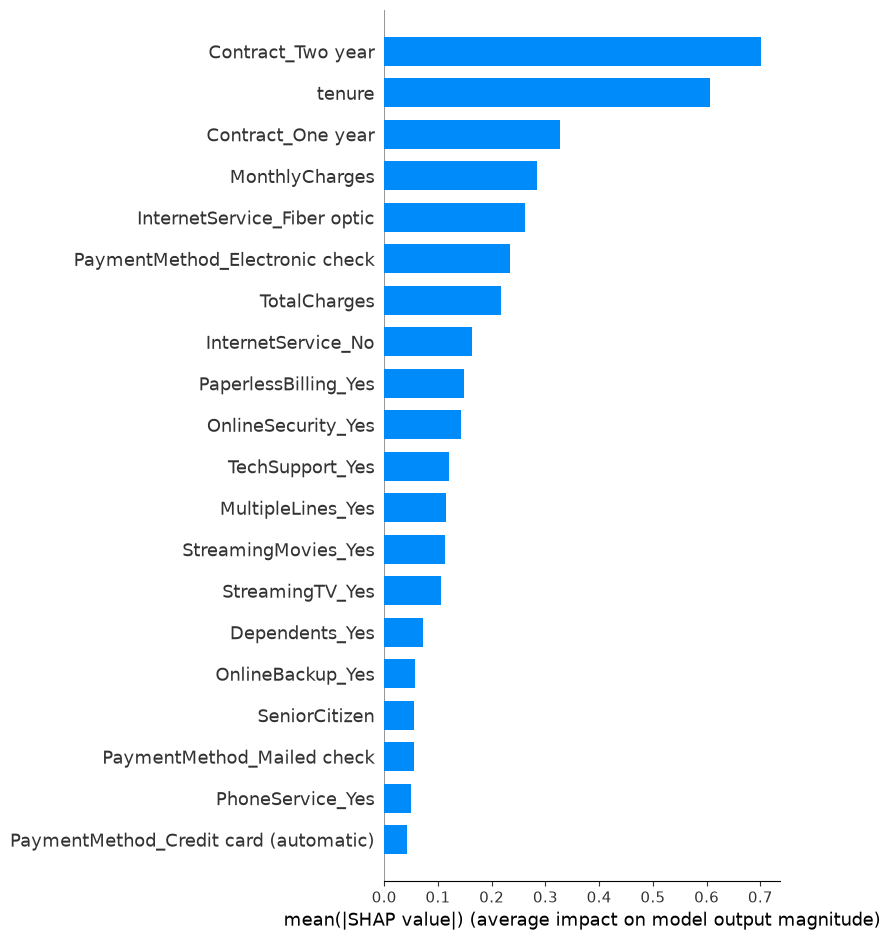

In [30]:
import shap

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

shap.summary_plot(shap_values_churn, X_test, plot_type="bar")

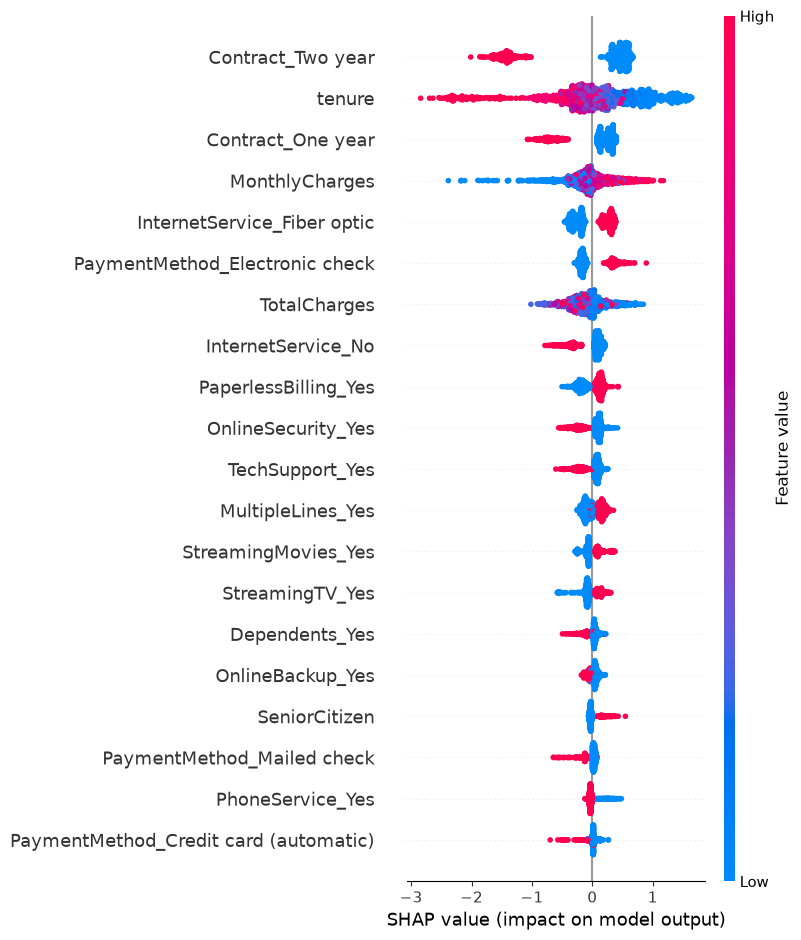

In [31]:
shap.summary_plot(shap_values_churn, X_test)

Predicted churn probability: 0.9728286358508097
Actual outcome: 1


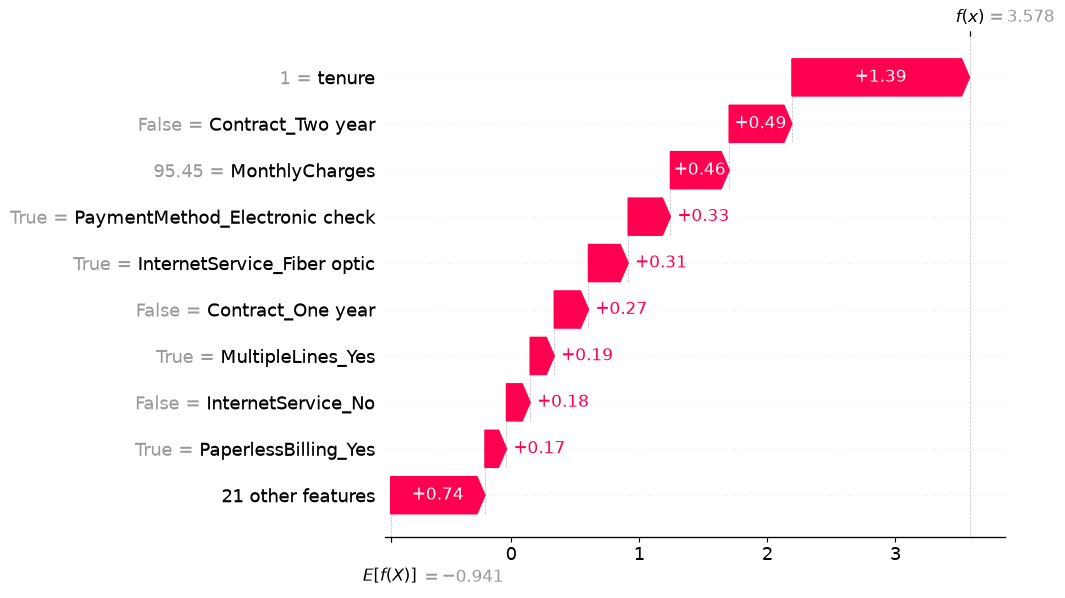

In [32]:
idx = y_proba_lgbm.argmax()
print("Predicted churn probability:", y_proba_lgbm[idx])
print("Actual outcome:", y_test.iloc[idx])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_churn[idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist()
    )
)

In [33]:
results_df = X_test.copy()
results_df["actual_churn"] = y_test.values
results_df["churn_probability"] = y_proba_lgbm

def risk_bucket(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

results_df["risk_segment"] = results_df["churn_probability"].apply(risk_bucket)

segment_summary = results_df.groupby("risk_segment").agg(
    customers=("actual_churn", "count"),
    actual_churn_rate=("actual_churn", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean")
).sort_values("actual_churn_rate", ascending=False)

print(segment_summary)

              customers  actual_churn_rate  avg_monthly_charges
risk_segment                                                   
High Risk           332           0.632530            77.056928
Medium Risk         321           0.330218            69.617290
Low Risk            756           0.076720            56.046495


In [34]:
avg_monthly_revenue_per_churner = results_df[results_df["actual_churn"] == 1]["MonthlyCharges"].mean()
retention_offer_cost = 15
retention_success_rate = 0.30
months_saved_per_retained = 12

high_risk = results_df[results_df["risk_segment"] == "High Risk"]
actual_churners_in_high_risk = high_risk["actual_churn"].sum()
customers_targeted = len(high_risk)
customers_retained = actual_churners_in_high_risk * retention_success_rate
revenue_saved = customers_retained * avg_monthly_revenue_per_churner * months_saved_per_retained
campaign_cost = customers_targeted * retention_offer_cost
net_benefit = revenue_saved - campaign_cost

print(f"High-risk customers targeted: {customers_targeted}")
print(f"Actual churners within that group: {actual_churners_in_high_risk}")
print(f"Estimated customers retained: {customers_retained:.0f}")
print(f"Revenue saved (12 months): {revenue_saved:,.2f}")
print(f"Campaign cost: {campaign_cost:,.2f}")
print(f"Net benefit: {net_benefit:,.2f}")

High-risk customers targeted: 332
Actual churners within that group: 210
Estimated customers retained: 63
Revenue saved (12 months): 55,011.94
Campaign cost: 4,980.00
Net benefit: 50,031.94


In [36]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

mlflow.set_experiment("churn_prediction")

# Log Logistic Regression (sklearn native — stays as is)
with mlflow.start_run(run_name="logistic_regression"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    y_pred_lr = baseline_pipeline.predict(X_test)
    y_proba_lr = baseline_pipeline.predict_proba(X_test)[:, 1]
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_lr))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, y_proba_lr))
    mlflow.sklearn.log_model(baseline_pipeline, "model")

# Log XGBoost — use mlflow.xgboost instead of mlflow.sklearn
with mlflow.start_run(run_name="xgboost"):
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_xgb))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, y_proba_xgb))
    mlflow.xgboost.log_model(xgb_model, "model")

# Log LightGBM — use mlflow.lightgbm instead of mlflow.sklearn
with mlflow.start_run(run_name="lightgbm"):
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_lgbm))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, y_proba_lgbm))
    mlflow.lightgbm.log_model(lgbm_model, "model")

print("All runs logged to MLflow.")

2026/10/03 18:00:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/10/03 18:00:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/03 18:00:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


All runs logged to MLflow.
